<>:83: SyntaxWarning: invalid escape sequence '\R'
<>:93: SyntaxWarning: invalid escape sequence '\I'
<>:83: SyntaxWarning: invalid escape sequence '\R'
<>:93: SyntaxWarning: invalid escape sequence '\I'
C:\Users\princ\AppData\Local\Temp\ipykernel_1664\4089862959.py:83: SyntaxWarning: invalid escape sequence '\R'
  label='Real Part $\Re(X)$'
C:\Users\princ\AppData\Local\Temp\ipykernel_1664\4089862959.py:93: SyntaxWarning: invalid escape sequence '\I'
  label='Imaginary Part $\Im(X)$'


 FFT AND IFFT EXPERIMENT

Original Signal:
[1 2 3 4 5 6 7 8]

FFT:
X[0] = 36.00 +0.00j
X[1] = -4.00 +9.66j
X[2] = -4.00 +4.00j
X[3] = -4.00 +1.66j
X[4] = -4.00 +0.00j
X[5] = -4.00 -1.66j
X[6] = -4.00 -4.00j
X[7] = -4.00 -9.66j

Magnitude Spectrum:
X[0] = 36.00
X[1] = 10.45
X[2] = 5.66
X[3] = 4.33
X[4] = 4.00
X[5] = 4.33
X[6] = 5.66
X[7] = 10.45

Phase Spectrum:
∠X[0] = 0.00°
∠X[1] = 112.50°
∠X[2] = 135.00°
∠X[3] = 157.50°
∠X[4] = 180.00°
∠X[5] = -157.50°
∠X[6] = -135.00°
∠X[7] = -112.50°

IFFT / Reconstructed Signal:
x[0] = 1.00
x[1] = 2.00
x[2] = 3.00
x[3] = 4.00
x[4] = 5.00
x[5] = 6.00
x[6] = 7.00
x[7] = 8.00


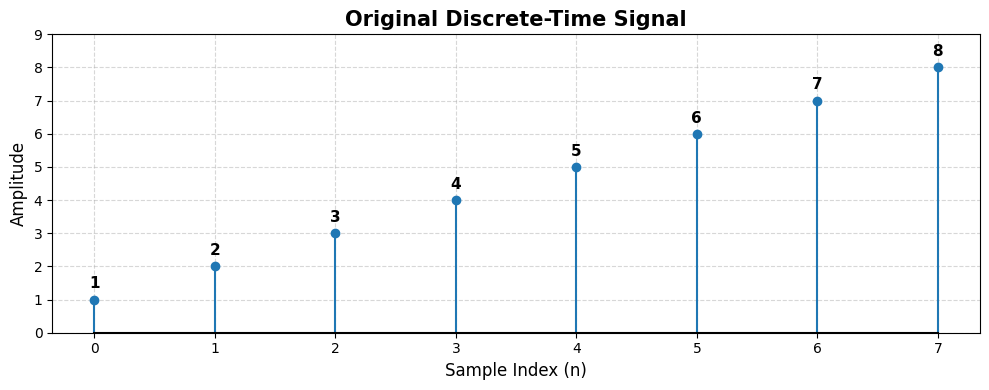

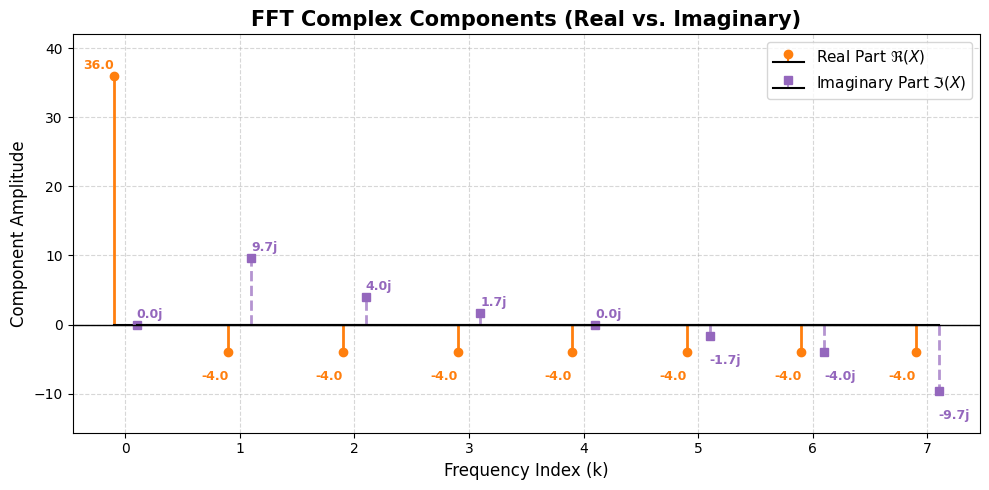

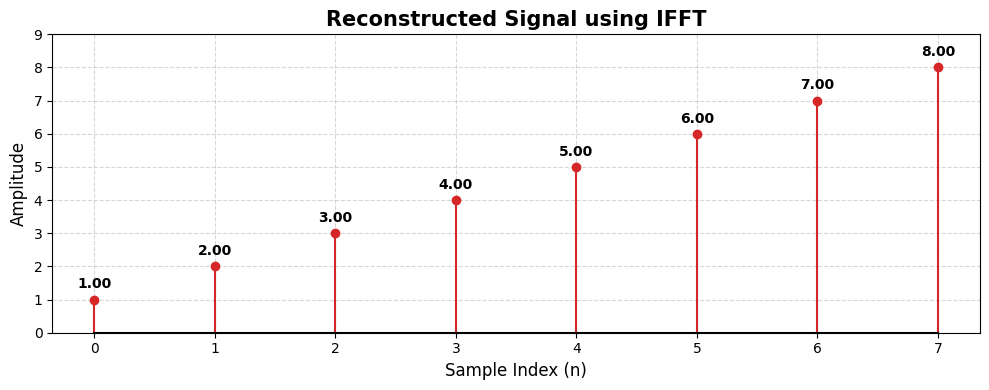

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# Input discrete-time signal
x = np.array([1, 2, 3, 4, 5, 6, 7, 8])
# Number of samples
N = len(x)
# Sample index
n = np.arange(N)

# FFT
X = np.fft.fft(x)
# Extract Real and Imaginary Parts
X_real = X.real
X_imag = X.imag
# Magnitude & Phase (Kept for print logs)
magnitude = np.abs(X)
phase = np.angle(X, deg=True)

# IFFT
x_reconstructed = np.fft.ifft(X)
# Remove very small imaginary values
x_reconstructed = np.real_if_close(x_reconstructed)
x_reconstructed = np.real(x_reconstructed)

# PRINT RESULTS
print(" FFT AND IFFT EXPERIMENT")
print("\nOriginal Signal:")
print(x)
print("\nFFT:")
for k in range(N):
    print(f"X[{k}] = {X[k].real:.2f} {X[k].imag:+.2f}j")
print("\nMagnitude Spectrum:")
for k in range(N):
    print(f"X[{k}] = {magnitude[k]:.2f}")
print("\nPhase Spectrum:")
for k in range(N):
    print(f"∠X[{k}] = {phase[k]:.2f}°")
print("\nIFFT / Reconstructed Signal:")
for k in range(N):
    print(f"x[{k}] = {x_reconstructed[k]:.2f}")

#ORIGINAL SIGNAL
plt.figure(figsize=(10, 4))
plt.stem(
    n,
    x,
    linefmt='C0-',
    markerfmt='C0o',
    basefmt='k-'
)
plt.title("Original Discrete-Time Signal", fontsize=15, fontweight='bold')
plt.xlabel("Sample Index (n)", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.xticks(n)
plt.yticks(np.arange(0, 10, 1))
plt.grid(True, linestyle='--', alpha=0.5)

# Data point values
for i in range(N):
    plt.text(
        i,
        x[i] + 0.25,
        f"{x[i]}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0, 9)
plt.tight_layout()
plt.show()

#FFT REAL & IMAGINARY PARTS
plt.figure(figsize=(10, 5))
# 1. Stem plot for Real Part (Shifted slightly left using k - 0.1 for visibility)
marker_real, stem_real, base_real = plt.stem(
    n - 0.1, 
    X_real, 
    linefmt='C1-', 
    markerfmt='C1o', 
    basefmt='k-', 
    label='Real Part $\Re(X)$'
)
plt.setp(stem_real, linewidth=2)
# 2. Stem plot for Imaginary Part (Shifted slightly right using k + 0.1 for visibility)
marker_imag, stem_imag, base_imag = plt.stem(
    n + 0.1, 
    X_imag, 
    linefmt='C4--', 
    markerfmt='C4s', 
    basefmt='k-', 
    label='Imaginary Part $\Im(X)$'
)
plt.setp(stem_imag, linewidth=2, alpha=0.7)
plt.title("FFT Complex Components (Real vs. Imaginary)", fontsize=15, fontweight='bold')
plt.xlabel("Frequency Index (k)", fontsize=12)
plt.ylabel("Component Amplitude", fontsize=12)

plt.xticks(n)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=1) # Reference line at zero
plt.legend(fontsize=11, loc='upper right')

# Add text values over/under stems dynamically
for k in range(N):
    # Text for Real Part
    y_pos_real = X_real[k] + 1.5 if X_real[k] >= 0 else X_real[k] - 3.5
    plt.text(k - 0.1, y_pos_real, f"{X_real[k]:.1f}", ha='right', va='center', color='C1', fontweight='bold', fontsize=9)
    # Text for Imaginary Part
    y_pos_imag = X_imag[k] + 1.5 if X_imag[k] >= 0 else X_imag[k] - 3.5
    plt.text(k + 0.1, y_pos_imag, f"{X_imag[k]:.1f}j", ha='left', va='center', color='C4', fontweight='bold', fontsize=9)

# Dynamically set y-limits with padding
all_vals = np.concatenate([X_real, X_imag])
plt.ylim(min(all_vals) - 6, max(all_vals) + 6)

plt.tight_layout()
plt.show()

# GRAPH 3: IFFT / RECONSTRUCTED SIGNAL
plt.figure(figsize=(10, 4))
plt.stem(
    n,
    x_reconstructed,
    linefmt='C3-',
    markerfmt='C3o',
    basefmt='k-'
)
plt.title(
    "Reconstructed Signal using IFFT",
    fontsize=15,
    fontweight='bold'
)
plt.xlabel("Sample Index (n)", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.xticks(n)
plt.yticks(np.arange(0, 10, 1))
plt.grid(True, linestyle='--', alpha=0.5)

# Data point values
for i in range(N):
    plt.text(
        i,
        x_reconstructed[i] + 0.25,
        f"{x_reconstructed[i]:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )
plt.ylim(0, 9)
plt.tight_layout()
plt.show()
